# V3 Uplift Model — Do-PFN

Do-PFN (NeurIPS 2025, arXiv 2506.06039) is a pre-trained transformer for causal effect estimation.  
Unlike the v2 IPW T-Learner, **Do-PFN handles confounding internally** — no separate propensity model is needed.  
It was meta-trained on millions of synthetic structural causal models (SCMs) and predicts interventional distributions directly.

**Treatment column must be first** in the feature matrix (hard architectural requirement).

**ITE convention** (consistent with v2): `ITE = P(churn | T=0, X) − P(churn | T=1, X)`  
Positive ITE → outreach reduces this member's churn probability (persuadable).

In [1]:
import os
import sys
import warnings
import pickle
warnings.filterwarnings('ignore')

DOPFN_REPO = '/tmp/do-pfn'

# Capture notebook's working directory before any chdir
DATA_DIR = os.getcwd()  # should be .../Shay_Assignment_Uplift/

# Add Do-PFN repo to import path
sys.path.insert(0, DOPFN_REPO)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

print(f'DATA_DIR : {DATA_DIR}')
print(f'DOPFN_REPO: {DOPFN_REPO}')

DATA_DIR : /Users/shayshavit/Claude/Projects/data-science-causality/Shay_Assignment_Uplift
DOPFN_REPO: /tmp/do-pfn


## 1. Load Data

In [2]:
train = pd.read_parquet(os.path.join(DATA_DIR, 'train_features.parquet'))
test  = pd.read_parquet(os.path.join(DATA_DIR, 'test_features.parquet'))

print(f'Train : {train.shape}  |  churn={train["churn"].mean():.3f}  outreach={train["outreach"].mean():.3f}')
print(f'Test  : {test.shape}')
print(f'\nTrain columns: {list(train.columns)}')

Train : (10000, 18)  |  churn=0.202  outreach=0.398
Test  : (10000, 15)

Train columns: ['member_id', 'tenure_days', 'churn', 'outreach', 'total_visits', 'wellco_visits', 'health_content_ratio', 'days_since_wellco', 'unique_wellco_domains', 'app_sessions', 'days_since_app', 'app_sessions_last7d', 'icd_E11_9', 'icd_I10', 'icd_Z71_3', 'unexpected_icd_count', 'expected_icd_count', 'propensity']


## 2. Prepare Features for Do-PFN

Do-PFN **requires treatment as column 0**. All other columns are covariates.

In [3]:
FEATURE_COLS = [
    'total_visits', 'wellco_visits', 'health_content_ratio',
    'days_since_wellco', 'unique_wellco_domains',
    'app_sessions', 'days_since_app', 'app_sessions_last7d',
    'icd_E11_9', 'icd_I10', 'icd_Z71_3',
    'unexpected_icd_count', 'expected_icd_count',
    'tenure_days'
]

# Treatment (outreach) FIRST, then the 14 covariates
DOPFN_COLS = ['outreach'] + FEATURE_COLS

X_train = train[DOPFN_COLS].values.astype(float)
y_train = train['churn'].values.astype(float)

# Test has no outreach column — prepend a placeholder column (will be set per intervention)
X_test_covariates = test[FEATURE_COLS].values.astype(float)
X_test_base = np.hstack([np.zeros((len(X_test_covariates), 1)), X_test_covariates])

print(f'X_train shape : {X_train.shape}  (col 0 = outreach)')
print(f'X_test_base   : {X_test_base.shape}')
print(f'Treatment prevalence in train: {X_train[:, 0].mean():.3f}')

X_train shape : (10000, 15)  (col 0 = outreach)
X_test_base   : (10000, 15)
Treatment prevalence in train: 0.398


## 3. Fit Do-PFN on Full Training Set

Do-PFN loads its pretrained weights from `artifacts/` via a relative path,  
so we `chdir` to the repo before instantiating.  
No propensity model needed — confounding adjustment is learned from the prior.

In [4]:
os.chdir(DOPFN_REPO)
from scripts.transformer_prediction_interface.base import DoPFNRegressor

model = DoPFNRegressor()
model.fit(X_train, y_train)
print(f'Do-PFN fitted on {len(X_train):,} training examples.')

Changed model to be compatible with CPU, this is needed for the current version of PyTorch, see issue: https://github.com/pytorch/pytorch/issues/97128. The model will be slower if reused on GPU.
Do-PFN fitted on 10,000 training examples.


## 4. Predict ITE on Test Set

`predict_cate(X)` computes `E[Y | do(T=1), X] − E[Y | do(T=0), X]`.  
Our sign convention is the reverse: **ITE = p0 − p1**, so `ITE = −predict_cate(X)`.

In [5]:
# predict_cate requires a torch tensor (it calls .cpu().detach() internally)
# predict_cate also modifies X[:,0] in place — the copy is already covered by tensor creation
X_test_tensor = torch.tensor(X_test_base.astype(np.float32))
cate_test = model.predict_cate(X_test_tensor)   # E[Y|T=1] - E[Y|T=0]
ite_test  = -np.asarray(cate_test)              # ITE = p0 - p1 (positive = outreach helps)

print('Test ITE statistics:')
print(f'  mean    : {ite_test.mean():.4f}')
print(f'  std     : {ite_test.std():.4f}')
print(f'  min/max : {ite_test.min():.3f} / {ite_test.max():.3f}')
print(f'  persuadable (ITE > 0): {(ite_test > 0).sum():,} / {len(ite_test):,}  ({(ite_test > 0).mean():.1%})')

Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

Running inference: 100%|██████████| 1/1 [00:25<00:00, 25.13s/batch]

Running inference: 100%|██████████| 1/1 [00:25<00:00, 25.13s/batch]

Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

Running inference: 100%|██████████| 1/1 [00:23<00:00, 23.93s/batch]

Running inference: 100%|██████████| 1/1 [00:23<00:00, 23.93s/batch]

Test ITE statistics:
  mean    : -0.1617
  std     : 0.1619
  min/max : -0.789 / 0.167
  persuadable (ITE > 0): 1,377 / 10,000  (13.8%)


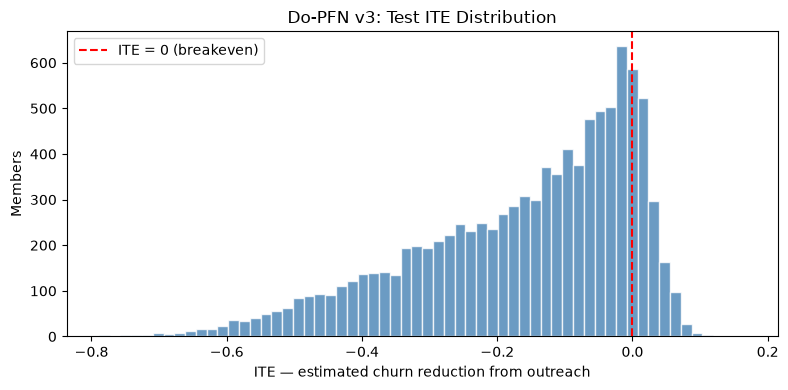

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ite_test, bins=60, edgecolor='white', alpha=0.8, color='steelblue')
ax.axvline(0, color='red', linestyle='--', lw=1.5, label='ITE = 0 (breakeven)')
ax.set_xlabel('ITE — estimated churn reduction from outreach')
ax.set_ylabel('Members')
ax.set_title('Do-PFN v3: Test ITE Distribution')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'ite_v3_dist.png'), dpi=100)
plt.show()

## 5. Cross-Validated ITE on Train (for Qini / AUUC in notebook 05)

5-fold CV with the same random seed as the v2 evaluation so results are directly comparable.

In [7]:
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
ite_cv = np.zeros(len(train))

# Stratify on joint churn × outreach to keep both axes balanced across folds
strat_key = (train['churn'].astype(str) + '_' + train['outreach'].astype(str)).values

X_train_f32 = X_train.astype(np.float32)

for fold_num, (tr_idx, val_idx) in enumerate(skf.split(X_train, strat_key)):
    print(f'Fold {fold_num + 1}/{N_FOLDS}  (n_train={len(tr_idx):,}, n_val={len(val_idx):,})')

    os.chdir(DOPFN_REPO)  # keep cwd on repo for artifact loading
    fold_model = DoPFNRegressor()
    fold_model.fit(X_train_f32[tr_idx], y_train[tr_idx])

    # predict_cate requires torch tensor
    X_val_tensor = torch.tensor(X_train_f32[val_idx])
    cate_val = fold_model.predict_cate(X_val_tensor)
    ite_cv[val_idx] = -np.asarray(cate_val)

print(f'\nCV ITE stats: mean={ite_cv.mean():.4f}, std={ite_cv.std():.4f}')
print(f'% persuadable (ITE > 0): {(ite_cv > 0).mean():.1%}')

Fold 1/5  (n_train=8,000, n_val=2,000)


Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

Running inference: 100%|██████████| 1/1 [00:09<00:00,  9.68s/batch]

Running inference: 100%|██████████| 1/1 [00:09<00:00,  9.68s/batch]

Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

...

Running inference: 100%|██████████| 1/1 [00:09<00:00,  9.02s/batch]

Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

Running inference: 100%|██████████| 1/1 [00:09<00:00,  9.27s/batch]

Running inference: 100%|██████████| 1/1 [00:09<00:00,  9.27s/batch]


CV ITE stats: mean=-0.1614, std=0.1626
% persuadable (ITE > 0): 13.9%


## 6. Save Outputs

In [8]:
# --- test_predictions_v3.parquet: v2 predictions + new v3 ITE column ---
test_preds_v2 = pd.read_parquet(os.path.join(DATA_DIR, 'test_predictions_v2.parquet'))

# Align by member_id to guard against any row-order differences
ite_series = pd.Series(ite_test, index=test['member_id'].values, name='ite_v3_dopfn')
test_preds_v3 = test_preds_v2.copy()
test_preds_v3['ite_v3_dopfn'] = test_preds_v3['member_id'].map(ite_series).values

test_preds_v3.to_parquet(os.path.join(DATA_DIR, 'test_predictions_v3.parquet'), index=False)
print(f'Saved test_predictions_v3.parquet  shape={test_preds_v3.shape}')

# --- predictions_v3_dopfn.csv: all 10k members ranked by ITE ---
pred_df = pd.DataFrame({
    'member_id': test['member_id'].values,
    'ite_score': ite_test,
})
pred_df['rank'] = pred_df['ite_score'].rank(ascending=False).astype(int)
pred_df = pred_df.sort_values('rank').reset_index(drop=True)
pred_df.to_csv(os.path.join(DATA_DIR, 'predictions_v3_dopfn.csv'), index=False)
print(f'Saved predictions_v3_dopfn.csv  ({len(pred_df):,} members)')
print(f'  ITE range: [{pred_df["ite_score"].min():.3f}, {pred_df["ite_score"].max():.3f}]')
print(f'  Persuadable (ITE > 0): {(pred_df["ite_score"] > 0).sum():,}')

# --- ite_cv_v3.pkl: cross-validated ITE for notebook 05 evaluation ---
cv_payload = {'ite_cv': ite_cv, 'member_ids': train['member_id'].values}
with open(os.path.join(DATA_DIR, 'ite_cv_v3.pkl'), 'wb') as f:
    pickle.dump(cv_payload, f)
print('Saved ite_cv_v3.pkl')

Saved test_predictions_v3.parquet  shape=(10000, 19)
Saved predictions_v3_dopfn.csv  (10,000 members)
  ITE range: [-0.789, 0.167]
  Persuadable (ITE > 0): 1,377
Saved ite_cv_v3.pkl
